In [1]:
import torch
import matplotlib.pyplot as plt
from torch import optim, distributions, nn
from tqdm.notebook import tqdm
import gpzoo
from gpzoo.kernels import NSF_RBF, batched_RBF, batched_MGGP_RBF
from gpzoo.gp import GaussianPrior, SVGP, VNNGP, MGGP_WSVGP
from gpzoo.likelihoods import PNMF, NSF2, Hybrid_NSF2
from gpzoo.utilities import whitened_KL, train_hybrid, train_hybrid_batched, anndata_to_train_val, plot_factors, rescale_spatial_coords, add_jitter, init_softplus
import squidpy as sq
import numpy as np
from sklearn.decomposition import NMF
import scanpy as sc
import random

from gpzoo.utilities import regularized_nmf, dims_autocorr
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import pickle
from sklearn.cluster import KMeans
import matplotlib.patheffects as path_effects


/gladstone/engelhardt/home/lchumpitaz/gitclones/GPzoo/gpzoo/utilities.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=1)

In [3]:
adata = sq.datasets.visium_hne_adata()

/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:956: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


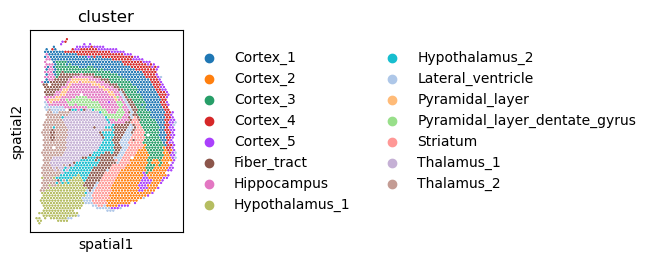

In [4]:
sq.pl.spatial_scatter(adata, color="cluster", size=1, shape=None);


<Axes: >

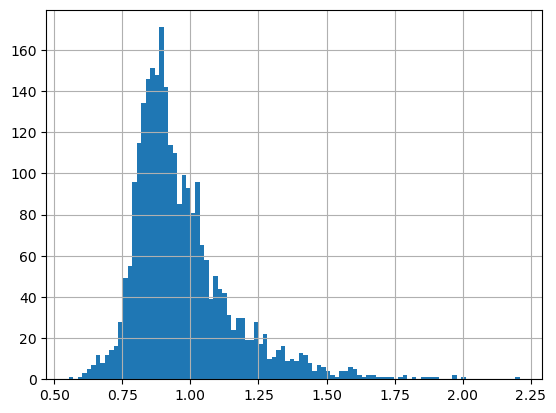

In [5]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
adata.obs.pct_counts_mt.hist(bins=100)

In [6]:
Dtr, Dval = anndata_to_train_val(adata, sz="scanpy")

In [7]:
Y = Dtr['Y'].T
X = Dtr['X']*50
V = Dtr['sz']

In [8]:
class ChromGP(nn.Module):
    def __init__(self, prior, kernel, noise=0.1, Z_noise=0.1, jitter=1e-5):
        super().__init__()
        self.prior = prior
        self.kernel = kernel
        self.jitter = jitter
        self.noise = nn.Parameter(torch.log(torch.exp(torch.tensor(noise)) - 1))
        # self.Z_noise = nn.Parameter(torch.log(torch.exp(torch.tensor(Z_noise)) - 1))

    def forward(self, E=1, verbose=False, **kwargs):
        noise = torch.nn.functional.softplus(self.noise) #ensure positive
        # Z_noise = torch.nn.functional.softplus(self.Z_noise)

        qZ, pZ = self.prior( **kwargs)
        Z = qZ.rsample().T
        Z = torch.squeeze(Z)
        # Z = torch.exp(Z)

        Kzz = kernel.forward(Z, Z)
        Kzz = Kzz.contiguous()
        Kzz = add_jitter(Kzz, self.jitter)
        N = len(Z)
        Kzz.view(-1)[::N+1]+= (noise**2)


        pY = distributions.MultivariateNormal(torch.zeros_like(torch.squeeze(Z[:,0])), Kzz)

        return pY, qZ, pZ

In [9]:
X = torch.tensor(X).type(torch.float)
Y = torch.tensor(Y).type(torch.float)
groupsX = torch.tensor(adata[Dtr['idx']].obs.cluster.values.codes).type(torch.LongTensor)
n_groups = len(adata.obs.cluster.values.categories)

<BarContainer object of 15 artists>

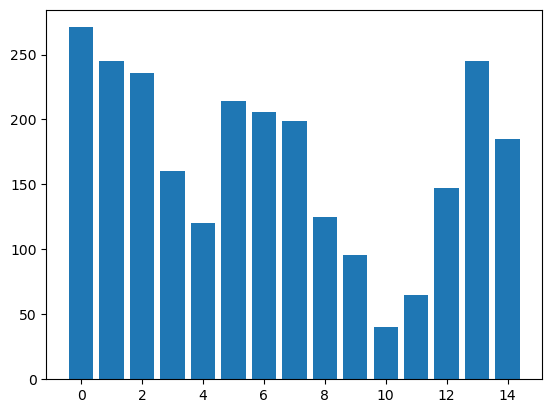

In [10]:
plt.bar(*torch.unique(groupsX, return_counts=True))

In [11]:
Y.shape

torch.Size([18078, 2554])

In [12]:
# groupsX = torch.tensor(adata[Dtr['idx']].obs.cluster.values.codes).type(torch.LongTensor)
# n_groups = len(adata.obs.cluster.values.categories)
M = 2554
L_dims = 2

jitter = 1e-5



# gp = MGGP_WSVGP(kernel_gp, M=M, jitter=jitter, n_groups=n_groups)
# gp.Lu = nn.Parameter(1e-2*torch.eye(M).clone())


prior = GaussianPrior(Y, L=L_dims)


U, _, _ = torch.svd(Y.T @ Y)

mu = 100.0*U[:, :L_dims]
# mu = 1e-1*torch.randn((L_dims,M))
prior.mean = nn.Parameter(mu.T)
scale_init = torch.nn.functional.softplus(torch.tensor(-1.0))
prior.scale = nn.Parameter(scale_init*torch.ones(M))


kernel = batched_RBF(sigma=1.0, lengthscale=1.0)


model = ChromGP(prior, kernel, noise=0.1, jitter=1e-4)



In [13]:
def train_batched(optimizer, model, y, device, steps=200, batch_size=1000, **kwargs):
    Zs = []

    # means = []
    # scales = []
    losses = []
    N = y.shape[1]

    
    for it in tqdm(range(steps)):

        # idx = torch.multinomial(torch.ones(N), num_samples=batch_size, replacement=False)

        y_batch = y[:, :]
        y_batch = y_batch.to(device)
        

        optimizer.zero_grad()

        
        pY, qZ, pZ = model()

        y_norm = y_batch- y_batch.mean(dim=1, keepdims=True)
        
        
        L1 = pY.log_prob(y_norm).sum()

        L1 = (L1*N)/batch_size
        # L2 = torch.sum(torch.vmap(whitened_KL)(qU.mean, qU.scale_tril))
        L2 = torch.sum(distributions.kl_divergence(qZ, pZ))

        log_prob = L1 - L2
        loss = -log_prob
        
        
        loss.backward()
        optimizer.step()        
        losses.append(loss.item())
        Zs.append(qZ.mean.T.detach().cpu().clone().numpy())



        y_batch = y_batch.cpu()

        del y_batch
    
    with torch.no_grad():
        if device.type=='cuda':
            torch.cuda.empty_cache()

    return losses, Zs#, means, scales

In [34]:
model.kernel.lengthscale.requires_grad = False
model.kernel.sigma.requires_grad = False
model.prior.scale.requires_grad=True
model.jitter=1e-4

In [35]:
optimizer = optim.Adam(model.parameters(), lr=1e-2)

In [36]:
def add_noise_mean(model, scale):
    with torch.no_grad():
        noise = scale * torch.randn_like(model.prior.mean)
        model.prior.mean.add_(noise)

# add_noise_mean(model, 1.0)

In [ ]:
model.to(device)
losses, Zs = train_batched(optimizer=optimizer, model=model, y=Y, device=device, steps=400*45, batch_size=Y.shape[1])

  0%|          | 0/18000 [00:00<?, ?it/s]

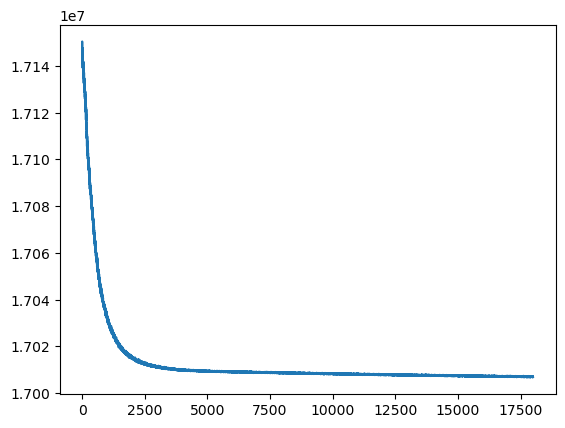

In [60]:
plt.plot(losses)

In [61]:
torch.nn.functional.softplus(model.prior.scale)

tensor([0.0055, 0.0053, 0.0057,  ..., 0.0052, 0.0063, 0.0095], device='cuda:1',
       grad_fn=<SoftplusBackward0>)

In [62]:
model.kernel.lengthscale

Parameter containing:
tensor(1., device='cuda:1')

In [63]:
Zs[-1]

array([[-1.1526221 , -0.88688284],
       [-1.014602  , -1.0844675 ],
       [-2.2100463 ,  0.28004378],
       ...,
       [-0.66318834,  2.7541287 ],
       [-1.312042  , -0.94213057],
       [-1.8136226 ,  0.5555391 ]], dtype=float32)

In [64]:
groupsX = torch.tensor(adata[Dtr['idx']].obs.cluster.values.codes).type(torch.LongTensor)
n_groups = len(adata.obs.cluster.values.categories)

/tmp/ipykernel_3831229/2559390886.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab20', n_groups)
/tmp/ipykernel_3831229/2559390886.py:35: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


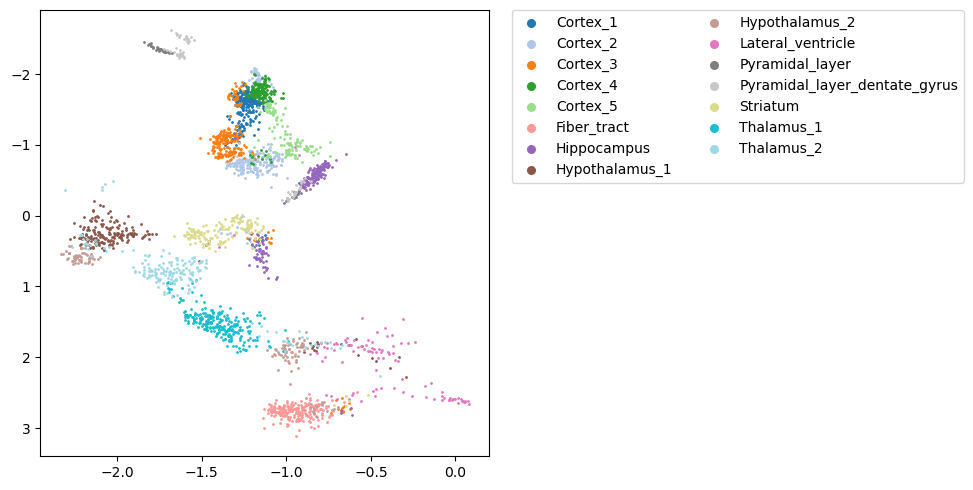

In [65]:
curr_training_idx = -1


import matplotlib.cm as cm
from matplotlib.legend_handler import HandlerPathCollection


plt.figure(figsize=(10,5))
# Extract cluster names
cluster_names = list(adata.obs.cluster.cat.categories)

colors = cm.get_cmap('tab20', n_groups)

for i in range(n_groups):
    idx = groupsX == i
    plt.scatter(
        Zs[curr_training_idx][idx][:, 0],
        Zs[curr_training_idx][idx][:, 1],
        s=1.0,
        label=cluster_names[i],  # Use the actual name here
        color=colors(i)
    )

plt.gca().invert_yaxis()

# Legend with larger dots and correct names
legend = plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    ncol=(n_groups + 9) // 10
)

# Enlarge the markers in the legend
for handle in legend.legendHandles:
    if hasattr(handle, "set_sizes"):
        handle.set_sizes([30])  # Adjust as needed

plt.tight_layout()
plt.show()